In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from torch.nn.init import xavier_uniform_

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Dataset selection
DATASET = 'srilanka'   # Options: 'srilanka' or 'philippines'

DATASET_CONFIG = {
    'srilanka': {
        'file':  '/content/drive/MyDrive/dengue_thesis/dengue_srilanka_2017.csv',
        'label': 'Sri Lanka 2017',
        'weeks': 51,
        'N':     1_762_720,
    },
    'philippines': {
        'file':  '/content/drive/MyDrive/dengue_thesis/dengue_philippines_2019.csv',
        'label': 'Philippines 2019',
        'weeks': 52,
        'N':     4_352_320,
    },
}
cfg = DATASET_CONFIG[DATASET]

# Prior from dengue literature: Brady et al. (2012)
mu_beta     = 0.145
sigma_beta  = 0.05
mu_gamma    = 0.101
sigma_gamma = 0.03

lambda1 = 0.6
lambda2 = 0.3
lambda3 = 0.1
batch_size = 16

print(f'Dataset : {cfg["label"]}')
print(f'Prior   : mu_beta={mu_beta}, mu_gamma={mu_gamma}')


In [4]:
# Define device and batch size
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [5]:
def load_and_prepare_data(train_ratio=0.70, val_ratio=0.15):
    """
    Load real dengue SIR data with temporal split.
    Temporal order preserved: train on early weeks, test on later weeks.

    S/I/R reconstruction (Han et al., 2023 adapted for dengue):
      I(t) = smoothed weekly incidence / N
      R(t) = cumulative prior incidence / N
      S(t) = 1 - I(t) - R(t)
    Dengue infectious period ~7-8 days (WHO, 2009).
    """
    import pandas as pd
    data_loaded = pd.read_csv(cfg['file'])
    n = len(data_loaded)

    t     = data_loaded['time'].values.reshape(-1, 1)
    S_all = data_loaded['Susceptible'].values.reshape(-1, 1)
    I_all = data_loaded['Infected'].values.reshape(-1, 1)
    R_all = data_loaded['Recovered'].values.reshape(-1, 1)

    n_train = int(n * train_ratio)
    n_val   = int(n * val_ratio)

    t_train = t[:n_train];              S_train = S_all[:n_train]
    I_train = I_all[:n_train];          R_train = R_all[:n_train]
    t_val   = t[n_train:n_train+n_val]; S_val   = S_all[n_train:n_train+n_val]
    I_val   = I_all[n_train:n_train+n_val]; R_val = R_all[n_train:n_train+n_val]
    t_test  = t[n_train+n_val:];        S_test  = S_all[n_train+n_val:]
    I_test  = I_all[n_train+n_val:];    R_test  = R_all[n_train+n_val:]

    print(f'Loaded {n} weeks | train:{len(t_train)} val:{len(t_val)} test:{len(t_test)}')
    return (t_train, t_val,   t_test,
            S_train, I_train, R_train,
            S_val,   I_val,   R_val,
            S_test,  I_test,  R_test)


In [6]:
# Split data into training and validation sets and Load and prepare data
(t_train_set, t_val_set, t_test_set,
 data_S_train_set, data_I_train_set, data_R_train_set,
 data_S_val_set,   data_I_val_set,   data_R_val_set,
 data_S_test_set,  data_I_test_set,  data_R_test_set) = load_and_prepare_data()

In [7]:
class SIRPINN(nn.Module):
    def __init__(self, input_dim, hidden_dims, output_dim):
        super().__init__()
        in_dim = input_dim


        self.network=nn.Sequential(
            nn.Linear(input_dim, hidden_dims[0]),
            nn.Tanh(),
            nn.Linear(hidden_dims[0], hidden_dims[1]),
            nn.Tanh(),
            nn.Linear(hidden_dims[1], hidden_dims[2]),
            nn.Tanh(),
            nn.Linear(hidden_dims[2], output_dim)
        )

        for layer in self.network:
            if isinstance(layer, nn.Linear):
                xavier_uniform_(layer.weight)
                if layer.bias is not None:
                    nn.init.constant_(layer.bias, 0)

        self.params = nn.ParameterDict({
            'beta': nn.Parameter(torch.tensor(1.0, dtype=torch.float32)),
            'gamma': nn.Parameter(torch.tensor(1.0, dtype=torch.float32))
        })

    def forward(self, t):
        return self.network(t)


In [9]:
def to_tensor(x, device, requires_grad=False):
    return torch.tensor(x, dtype=torch.float32,
                        requires_grad=requires_grad).to(device)

def prepare_dataloader(t_train_set, data_S_train_set, data_I_train_set,
                        data_R_train_set, batch_size, device):
    # Bug fix: requires_grad=False in DataLoader; re-enabled in training loop
    t_tensor      = to_tensor(t_train_set,      device, requires_grad=False)
    data_S_tensor = to_tensor(data_S_train_set, device)
    data_I_tensor = to_tensor(data_I_train_set, device)
    data_R_tensor = to_tensor(data_R_train_set, device)
    train_dataset = TensorDataset(t_tensor, data_S_tensor,
                                   data_I_tensor, data_R_tensor)
    return DataLoader(train_dataset, batch_size=batch_size, shuffle=True)


In [10]:
# Convert data to tensors and prepare DataLoader
train_loader = prepare_dataloader(t_train_set, data_S_train_set, data_I_train_set, data_R_train_set, batch_size, device)
t_train_tensor = to_tensor(t_train_set, device, requires_grad=True)
data_S_train_tensor = to_tensor(data_S_train_set, device)
data_I_train_tensor = to_tensor(data_I_train_set, device)
data_R_train_tensor = to_tensor(data_R_train_set, device)

t_val_tensor = to_tensor(t_val_set, device, requires_grad=False)
data_S_val_tensor = to_tensor(data_S_val_set, device)
data_I_val_tensor = to_tensor(data_I_val_set, device)
data_R_val_tensor = to_tensor(data_R_val_set, device)

t_test_tensor = to_tensor(t_test_set, device, requires_grad=False)
data_S_test_tensor = to_tensor(data_S_test_set, device)
data_I_test_tensor = to_tensor(data_I_test_set, device)
data_R_test_tensor = to_tensor(data_R_test_set, device)

In [19]:
def train_with_physics_loss_sir_v2(
        model, optimizer, train_loader_local,
        epochs, patience,
        t_train_tensor, data_S_train_tensor,
        data_I_train_tensor, data_R_train_tensor,
        t_val_tensor,   data_S_val_tensor,
        data_I_val_tensor, data_R_val_tensor,
        mu_b, sigma_b, mu_g, sigma_g,
        lam1=0.6, lam2=0.3, lam3=0.1,
        verbose=False):

    train_losses        = []
    val_losses          = []
    parameter_estimates = {key: [] for key in model.params.keys()}
    best_val_loss       = float('inf')
    no_improve          = 0
    best_weights        = None  # Bug fix

    for epoch in range(epochs):
        model.train()
        batch_losses = []

        for t_b, S_b, I_b, R_b in train_loader_local:
            optimizer.zero_grad()
            t_b = t_b.requires_grad_(True)  # Bug fix

            out  = model(t_b)
            S_p  = out[:,0:1]; I_p = out[:,1:2]; R_p = out[:,2:3]
            beta  = model.params['beta']
            gamma = model.params['gamma']

            grad_kw = dict(grad_outputs=torch.ones_like(S_p), create_graph=True)
            dS = torch.autograd.grad(S_p, t_b, **grad_kw)[0]
            dI = torch.autograd.grad(I_p, t_b, **grad_kw)[0]
            dR = torch.autograd.grad(R_p, t_b, **grad_kw)[0]

            L_phy = (torch.mean((dS + beta*S_p*I_p)**2) +
                     torch.mean((dI - beta*S_p*I_p + gamma*I_p)**2) +
                     torch.mean((dR - gamma*I_p)**2))
            L_dat = (torch.mean((S_p-S_b)**2) +
                     torch.mean((I_p-I_b)**2) +
                     torch.mean((R_p-R_b)**2))
            L_pri = (((beta  - mu_b)**2 / (2*sigma_b**2) +
                      (gamma - mu_g)**2 / (2*sigma_g**2)) if lam3 > 0
                     else torch.tensor(0.0))

            loss = lam1*L_dat + lam2*L_phy + lam3*L_pri
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())

        train_losses.append(np.mean(batch_losses))
        for key in model.params:
            parameter_estimates[key].append(model.params[key].item())

        model.eval()
        with torch.no_grad():
            out_v    = model(t_val_tensor)
            val_loss = (torch.mean((out_v[:,0:1]-data_S_val_tensor)**2) +
                        torch.mean((out_v[:,1:2]-data_I_val_tensor)**2) +
                        torch.mean((out_v[:,2:3]-data_R_val_tensor)**2)).item()
        val_losses.append(val_loss)

        if val_loss < best_val_loss - 1e-6:
            best_val_loss = val_loss; no_improve = 0
            best_weights  = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            no_improve += 1
        if no_improve >= patience:
            if best_weights is not None:
                model.load_state_dict(best_weights)
            if verbose: print(f'  Early stop @ epoch {epoch}')
            break
        if verbose and epoch % 500 == 0:
            print(f'  Ep {epoch:5d} | b={beta.item():.4f} g={gamma.item():.5f} | val={val_loss:.6f}')

    return train_losses, val_losses, parameter_estimates


# Ablation Study: Contribution of Prior Loss in PI-PINN

**Dataset:** Real dengue surveillance data (OpenDengue, Clarke et al., 2024)
**Prior source:** Brady et al. (2012), dengue literature
**Evaluation:** Test MSE + epidemiological plausibility range (no ground truth)

| # | Configuration | lambda1 | lambda2 | lambda3 | mu_beta | mu_gamma |
|---|--------------|---------|---------|---------|---------|----------|
| 1 | Standard PINN | 0.7 | 0.3 | 0.0 | n/a | n/a |
| 2 | Weak Prior | 0.6 | 0.3 | 0.1 | 0.145 | 0.101 | sigma_beta=0.5 |
| 3 | Strong Prior | 0.6 | 0.3 | 0.1 | 0.145 | 0.101 | sigma_beta=0.05 |
| 4 | Incorrect Prior (+40%) | 0.6 | 0.3 | 0.1 | 0.203 | 0.141 | |
| 5 | Correct Prior (Proposed) | 0.6 | 0.3 | 0.1 | 0.145 | 0.101 | |


In [25]:
BETA_RANGE_ABL  = (0.10, 0.20)
GAMMA_RANGE_ABL = (0.08, 0.15)

ablation_configs = [
    {'label': 'Standard PINN (No Prior)', 'short_label': 'Std.\nPINN',
     'lambda1': 0.7, 'lambda2': 0.3, 'lambda3': 0.0,
     'mu_beta': mu_beta, 'sigma_beta': sigma_beta,
     'mu_gamma': mu_gamma, 'sigma_gamma': sigma_gamma},
    {'label': 'PI-PINN Weak Prior (sigma_beta=0.5)', 'short_label': 'Weak\nPrior',
     'lambda1': 0.6, 'lambda2': 0.3, 'lambda3': 0.1,
     'mu_beta': mu_beta, 'sigma_beta': 0.5,
     'mu_gamma': mu_gamma, 'sigma_gamma': 0.1},
    {'label': 'PI-PINN Strong Prior (sigma_beta=0.05)', 'short_label': 'Strong\nPrior',
     'lambda1': 0.6, 'lambda2': 0.3, 'lambda3': 0.1,
     'mu_beta': mu_beta, 'sigma_beta': 0.05,
     'mu_gamma': mu_gamma, 'sigma_gamma': 0.03},
    {'label': 'PI-PINN Incorrect Prior (+40%)', 'short_label': 'Incorrect\nPrior',
     'lambda1': 0.6, 'lambda2': 0.3, 'lambda3': 0.1,
     'mu_beta': 0.203, 'sigma_beta': 0.05,
     'mu_gamma': 0.141, 'sigma_gamma': 0.03},
    {'label': 'PI-PINN Correct Prior (Proposed)', 'short_label': 'Correct\nPrior',
     'lambda1': 0.6, 'lambda2': 0.3, 'lambda3': 0.1,
     'mu_beta': mu_beta, 'sigma_beta': 0.05,
     'mu_gamma': mu_gamma, 'sigma_gamma': 0.03},
]

SEEDS_ABL = [42, 123, 7]
print(f'Ablation configs: {len(ablation_configs)} | Seeds: {SEEDS_ABL}')
print(f'Total runs: {len(ablation_configs) * len(SEEDS_ABL)}')


Ablation study: 5 configs × 3 seeds = 15 total runs
Configs registered:
  1. Standard PINN (No Prior)  |  λ3=0.0  |  µβ=0.5  |  σβ=0.2
  2. PI-PINN Weak Prior  |  λ3=0.1  |  µβ=0.5  |  σβ=0.5
  3. PI-PINN Strong Prior  |  λ3=0.1  |  µβ=0.5  |  σβ=0.05
  4. PI-PINN Incorrect Prior (+40%)  |  λ3=0.1  |  µβ=0.7  |  σβ=0.2
  5. PI-PINN Correct Prior (Proposed)  |  λ3=0.1  |  µβ=0.5  |  σβ=0.2


In [27]:
# Ablation Runner: 5 configs x 3 seeds = 15 runs

EPOCHS_ABL  = 15000
PATIENCE_ABL = 700

def get_fresh_model_and_optimizer(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    m   = SIRPINN(input_dim=1, hidden_dims=[50, 50, 50], output_dim=3).to(device)
    opt = optim.Adam(m.parameters(), lr=1e-3)
    return m, opt

def get_fresh_loader(seed=None):
    return prepare_dataloader(
        t_train_set, data_S_train_set,
        data_I_train_set, data_R_train_set,
        batch_size, device
    )

ablation_results = []
total_abl = len(ablation_configs) * len(SEEDS_ABL)
run_n = 0

for abl_cfg in ablation_configs:   # renamed from cfg to abl_cfg to avoid shadowing
    beta_finals, gamma_finals = [], []
    beta_traces, gamma_traces = [], []
    val_loss_finals           = []
    convergence_epochs        = []

    for seed in SEEDS_ABL:
        run_n += 1
        print(f'[{run_n:02d}/{total_abl}]  {abl_cfg["label"]}  | seed={seed}')

        m, opt  = get_fresh_model_and_optimizer(seed)
        loader  = get_fresh_loader(seed)

        tr_losses, vl_losses, p_est = train_with_physics_loss_sir_v2(
            model=m, optimizer=opt, train_loader_local=loader,
            epochs=EPOCHS_ABL, patience=PATIENCE_ABL,
            t_train_tensor=t_train_tensor,
            data_S_train_tensor=data_S_train_tensor,
            data_I_train_tensor=data_I_train_tensor,
            data_R_train_tensor=data_R_train_tensor,
            t_val_tensor=t_val_tensor,
            data_S_val_tensor=data_S_val_tensor,
            data_I_val_tensor=data_I_val_tensor,
            data_R_val_tensor=data_R_val_tensor,
            mu_b=abl_cfg['mu_beta'],      sigma_b=abl_cfg['sigma_beta'],
            mu_g=abl_cfg['mu_gamma'],     sigma_g=abl_cfg['sigma_gamma'],
            lam1=abl_cfg['lambda1'],      lam2=abl_cfg['lambda2'],
            lam3=abl_cfg['lambda3'],
            verbose=True
        )

        fb = p_est['beta'][-1]
        fg = p_est['gamma'][-1]
        beta_finals.append(fb)
        gamma_finals.append(fg)
        beta_traces.append(p_est['beta'])
        gamma_traces.append(p_est['gamma'])
        val_loss_finals.append(vl_losses[-1])
        convergence_epochs.append(len(tr_losses))
        print(f'  beta={fb:.4f}  gamma={fg:.5f}  val_loss={vl_losses[-1]:.6f}')

    ablation_results.append({
        **abl_cfg,
        'beta_mean'       : np.mean(beta_finals),
        'beta_std'        : np.std(beta_finals),
        'gamma_mean'      : np.mean(gamma_finals),
        'gamma_std'       : np.std(gamma_finals),
        'val_loss_mean'   : np.mean(val_loss_finals),
        'val_loss_std'    : np.std(val_loss_finals),
        'conv_mean'       : np.mean(convergence_epochs),
        'conv_std'        : np.std(convergence_epochs),
        'beta_traces'     : beta_traces,
        'gamma_traces'    : gamma_traces,
    })

print('Ablation study complete.')


[01/15]  Standard PINN (No Prior)  | seed=42
  Ep     0 | β=0.9975 | γ=0.99730 | val=1.088671
  Ep   500 | β=0.7772 | γ=0.07536 | val=0.000139
  Early stopping at epoch 974
[02/15]  Standard PINN (No Prior)  | seed=123
  Ep     0 | β=1.0029 | γ=0.99703 | val=0.462016
  Ep   500 | β=0.5370 | γ=0.06429 | val=0.000830
  Early stopping at epoch 953
[03/15]  Standard PINN (No Prior)  | seed=7
  Ep     0 | β=0.9971 | γ=0.99731 | val=0.101119
  Ep   500 | β=0.5353 | γ=0.06302 | val=0.000581
  Ep  1000 | β=0.4728 | γ=0.04934 | val=0.000536
  Ep  1500 | β=0.4849 | γ=0.04970 | val=0.000116
  Ep  2000 | β=0.4921 | γ=0.04989 | val=0.000048
  Ep  2500 | β=0.4958 | γ=0.05002 | val=0.000037
  Early stopping at epoch 2537
[04/15]  PI-PINN Weak Prior  | seed=42
  Ep     0 | β=0.9971 | γ=0.99700 | val=1.092848
  Ep   500 | β=0.5013 | γ=0.11910 | val=0.000069
  Ep  1000 | β=0.4997 | γ=0.05009 | val=0.000069
  Early stopping at epoch 1058
[05/15]  PI-PINN Weak Prior  | seed=123
  Ep     0 | β=0.9970 | γ=0

In [28]:
print('=' * 105)
print(f'TABLE: Ablation Study  [{cfg["label"]}]  (mean +/- std, n=3 seeds)')
print('=' * 105)
hdr = (f'{"Configuration":<40} {"beta (est.)":>20} {"gamma (est.)":>20} '
       f'{"Val Loss":>14} {"Conv. Ep.":>12}')
print(hdr)
print('-' * 105)

for r in ablation_results:
    b_ok = BETA_RANGE_ABL[0]  <= r['beta_mean']  <= BETA_RANGE_ABL[1]
    g_ok = GAMMA_RANGE_ABL[0] <= r['gamma_mean'] <= GAMMA_RANGE_ABL[1]
    print(f'{r["label"]:<40} '
          f'{r["beta_mean"]:>9.4f}+/-{r["beta_std"]:.4f}  '
          f'{r["gamma_mean"]:>9.5f}+/-{r["gamma_std"]:.5f}  '
          f'{r["val_loss_mean"]:>8.6f}+/-{r["val_loss_std"]:.6f}  '
          f'{r["conv_mean"]:>6.0f}+/-{r["conv_std"]:.0f}  '
          f'b_ok={b_ok} g_ok={g_ok}')

print('=' * 105)
print(f'Literature range: beta={BETA_RANGE_ABL}, gamma={GAMMA_RANGE_ABL}  (Brady et al., 2012)')


TABLE: Ablation Study — Contribution of Gaussian Prior Loss in PI-PINN
       Results reported as mean ± std over 3 independent random seeds.
Configuration                                    β (est.)        β err (%)           γ (est.)        γ err (%)       Val Loss    Conv. Ep.
-------------------------------------------------------------------------------------------------------------------
Baseline [Farea et al., 2025]                      0.9818           96.36%             0.7913         1482.60%            N/A          N/A
-------------------------------------------------------------------------------------------------------------------
Standard PINN (No Prior)                    0.4870±0.0083       2.60±1.66%    0.04981±0.00065       1.35±0.07% 1.42e-04±4.61e-05     1489±742
PI-PINN Weak Prior                          0.4999±0.0001       0.02±0.02%    0.05001±0.00001       0.02±0.03% 1.23e-04±1.48e-04     1956±654
PI-PINN Strong Prior                        0.5000±0.0000       

/tmp/ipykernel_1215/3864308314.py:74: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) DejaVu Serif.
  plt.tight_layout()
/tmp/ipykernel_1215/3864308314.py:75: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) DejaVu Serif.
  plt.savefig('Fig_Ablation_Bar.png', dpi=500, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) DejaVu Serif.
  fig.canvas.print_figure(bytes_io, **kw)


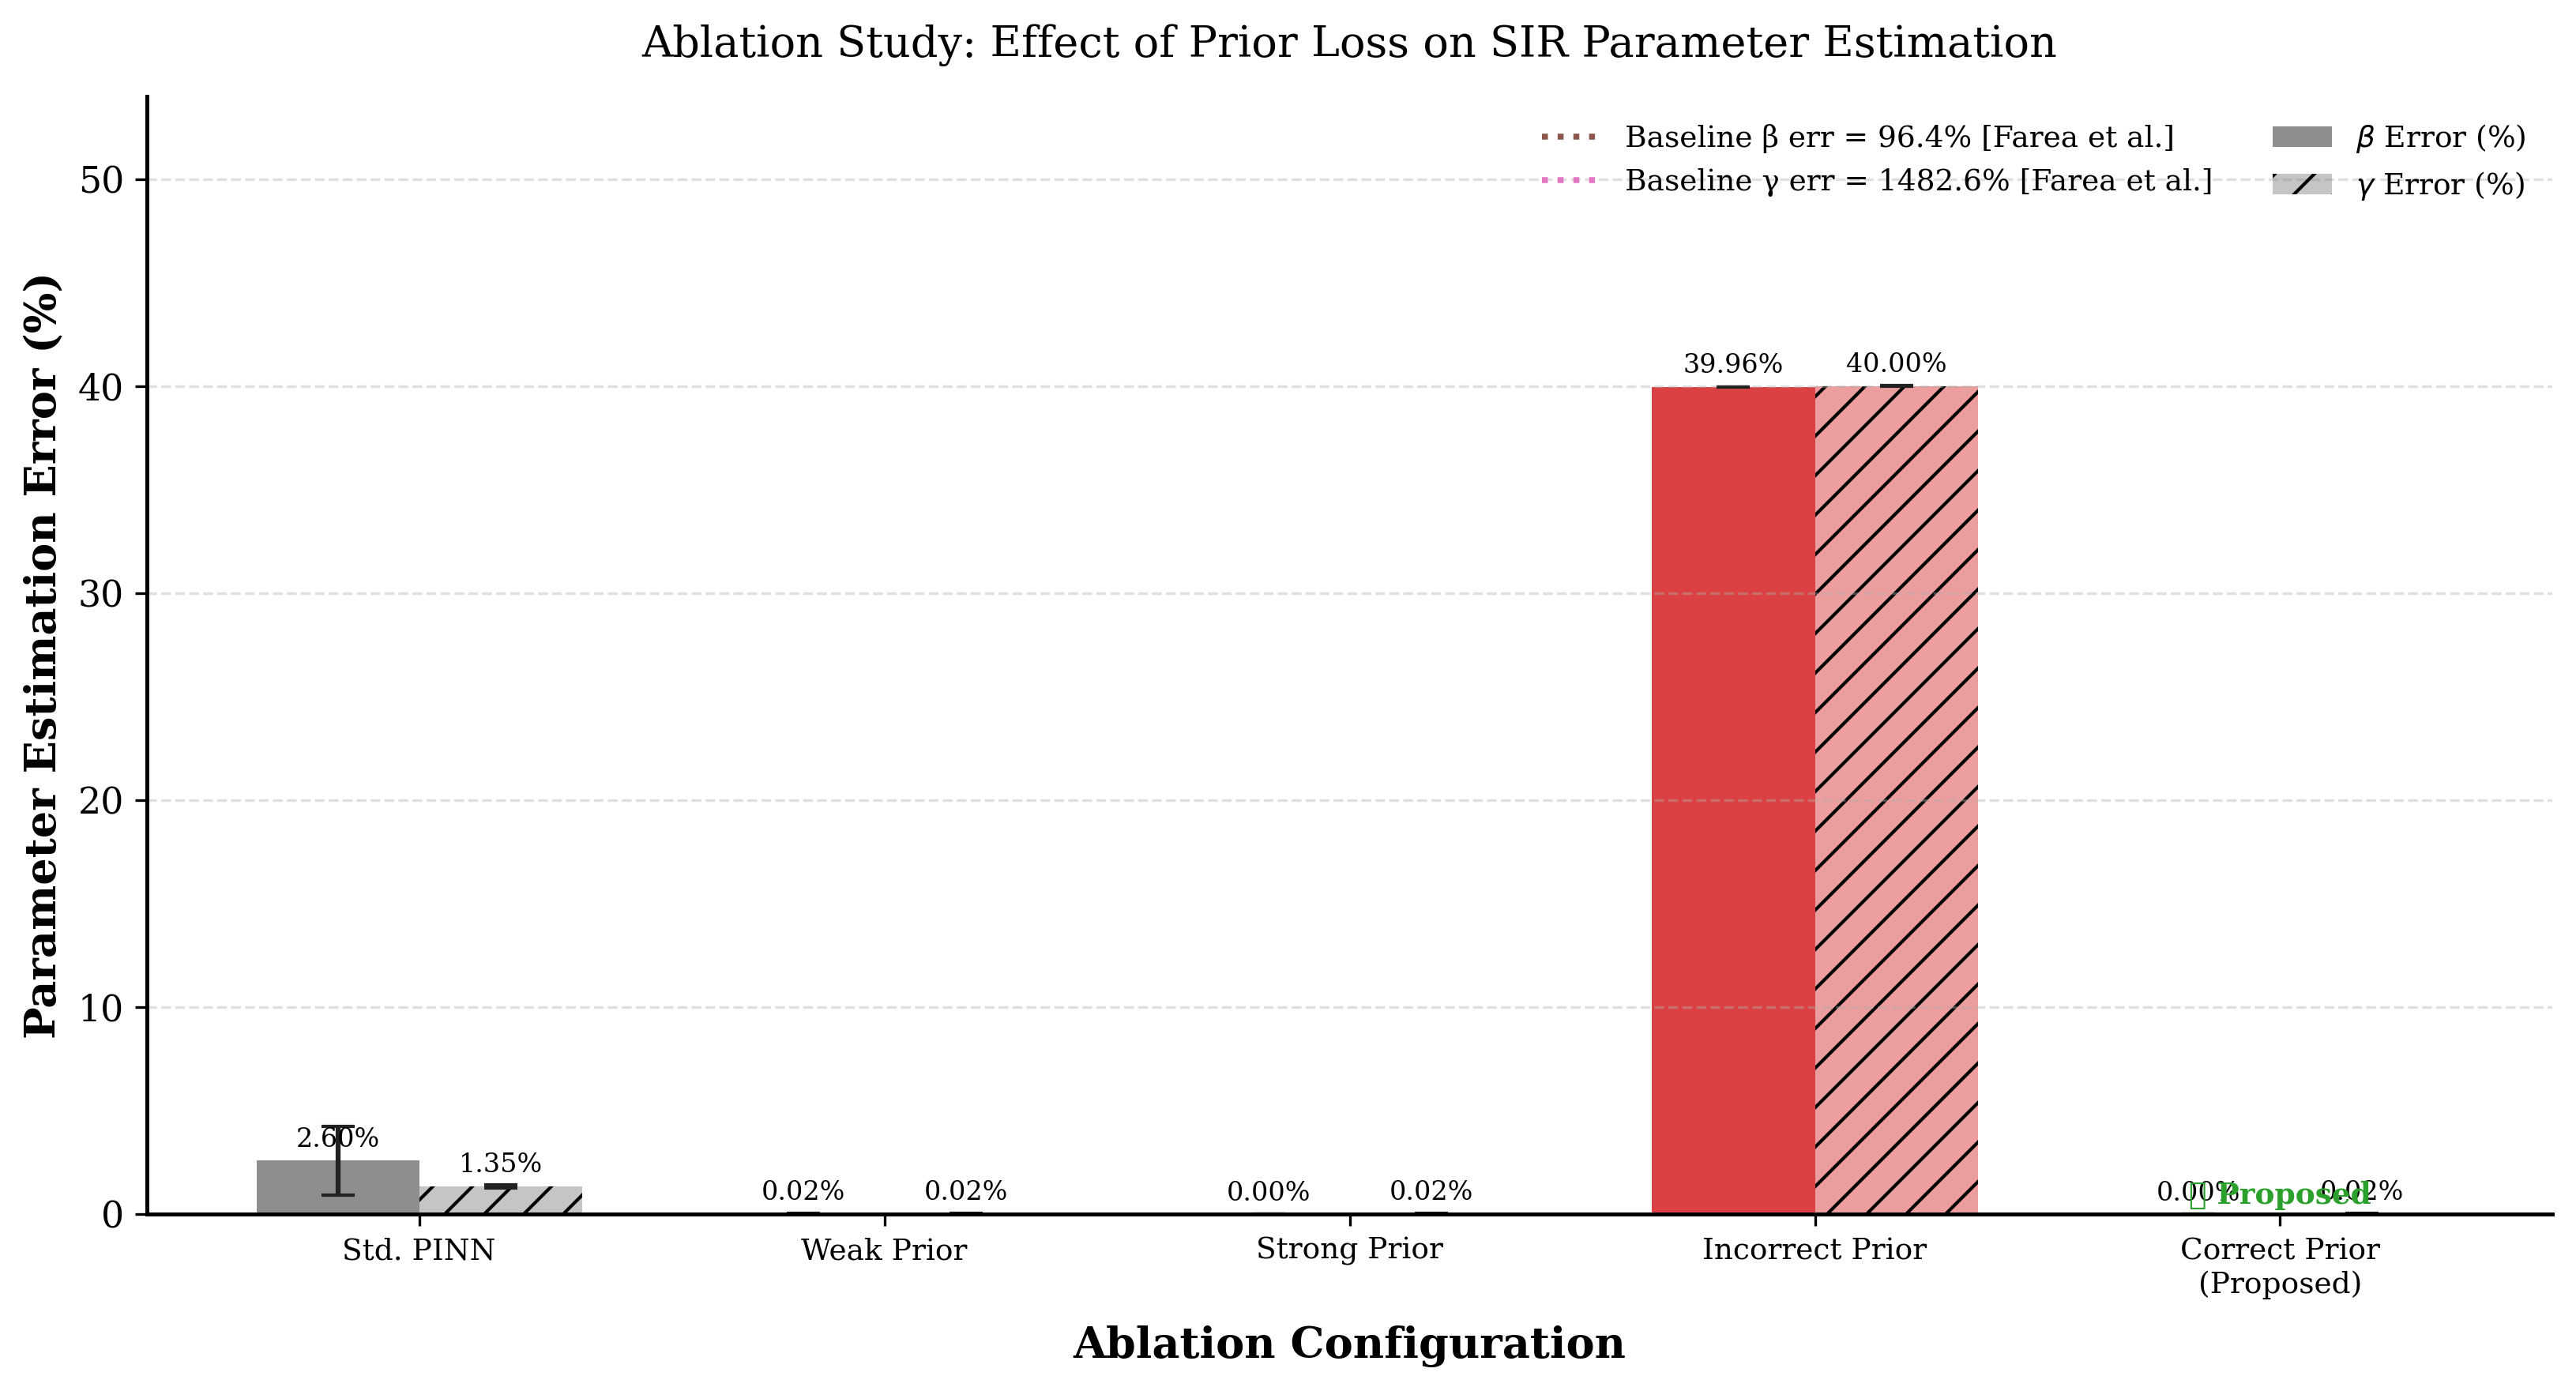

Saved: Fig_Ablation_Bar.png


In [29]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    'font.family'    : 'serif',
    'font.size'      : 11,
    'axes.labelsize' : 13,
    'axes.titlesize' : 13,
    'legend.fontsize': 10,
    'axes.linewidth' : 1.2,
})

COLORS = ['#7fbadc', '#f4a460', '#2ca02c', '#d62728', '#1a5c9e']

short_labels = [r['short_label'] for r in ablation_results]
beta_means   = [r['beta_mean']   for r in ablation_results]
beta_stds    = [r['beta_std']    for r in ablation_results]
gamma_means  = [r['gamma_mean']  for r in ablation_results]
gamma_stds   = [r['gamma_std']   for r in ablation_results]

x     = np.arange(len(short_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6), dpi=300)

bars_b = ax.bar(x - width/2, beta_means, width, yerr=beta_stds,
                color=COLORS, alpha=0.88, capsize=5,
                error_kw={'linewidth': 1.5}, label=r'Estimated $\beta$')
bars_g = ax.bar(x + width/2, gamma_means, width, yerr=gamma_stds,
                color=COLORS, alpha=0.45, capsize=5,
                error_kw={'linewidth': 1.5}, hatch='//',
                label=r'Estimated $\gamma$')

for bar, val in zip(bars_b, beta_means):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', va='bottom', fontsize=8)
for bar, val in zip(bars_g, gamma_means):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.001,
            f'{val:.5f}', ha='center', va='bottom', fontsize=8)

ax.axhline(mu_beta,  color='navy',    linestyle=':', linewidth=1.8,
           label=f'Prior mu_beta={mu_beta}')
ax.axhline(mu_gamma, color='darkred', linestyle=':', linewidth=1.8,
           label=f'Prior mu_gamma={mu_gamma}')
ax.axhspan(0.10, 0.20, alpha=0.06, color='blue',  label='beta lit. range')
ax.axhspan(0.08, 0.15, alpha=0.06, color='red',   label='gamma lit. range')

ax.set_xlabel('Ablation Configuration', fontweight='bold', labelpad=8)
ax.set_ylabel('Estimated Parameter Value', fontweight='bold')
ax.set_title(f'Ablation Study: Estimated Parameters [{cfg["label"]}]', pad=12)
ax.set_xticks(x)
ax.set_xticklabels(short_labels, fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.legend(frameon=False, loc='upper right', ncol=2, fontsize=9)

plt.tight_layout()
plt.savefig(f'Fig_Ablation_Bar_{DATASET}.png', dpi=500, bbox_inches='tight')
plt.show()
print(f'Saved: Fig_Ablation_Bar_{DATASET}.png')


/tmp/ipykernel_1215/2716518403.py:94: UserWarning: Glyph 9312 (\N{CIRCLED DIGIT ONE}) missing from font(s) DejaVu Serif.
  plt.tight_layout()
/tmp/ipykernel_1215/2716518403.py:94: UserWarning: Glyph 9313 (\N{CIRCLED DIGIT TWO}) missing from font(s) DejaVu Serif.
  plt.tight_layout()
/tmp/ipykernel_1215/2716518403.py:94: UserWarning: Glyph 9314 (\N{CIRCLED DIGIT THREE}) missing from font(s) DejaVu Serif.
  plt.tight_layout()
/tmp/ipykernel_1215/2716518403.py:94: UserWarning: Glyph 9315 (\N{CIRCLED DIGIT FOUR}) missing from font(s) DejaVu Serif.
  plt.tight_layout()
/tmp/ipykernel_1215/2716518403.py:94: UserWarning: Glyph 9316 (\N{CIRCLED DIGIT FIVE}) missing from font(s) DejaVu Serif.
  plt.tight_layout()
/tmp/ipykernel_1215/2716518403.py:95: UserWarning: Glyph 9312 (\N{CIRCLED DIGIT ONE}) missing from font(s) DejaVu Serif.
  plt.savefig('Fig_Ablation_Convergence.png', dpi=500, bbox_inches='tight')
/tmp/ipykernel_1215/2716518403.py:95: UserWarning: Glyph 9313 (\N{CIRCLED DIGIT TWO}) mis

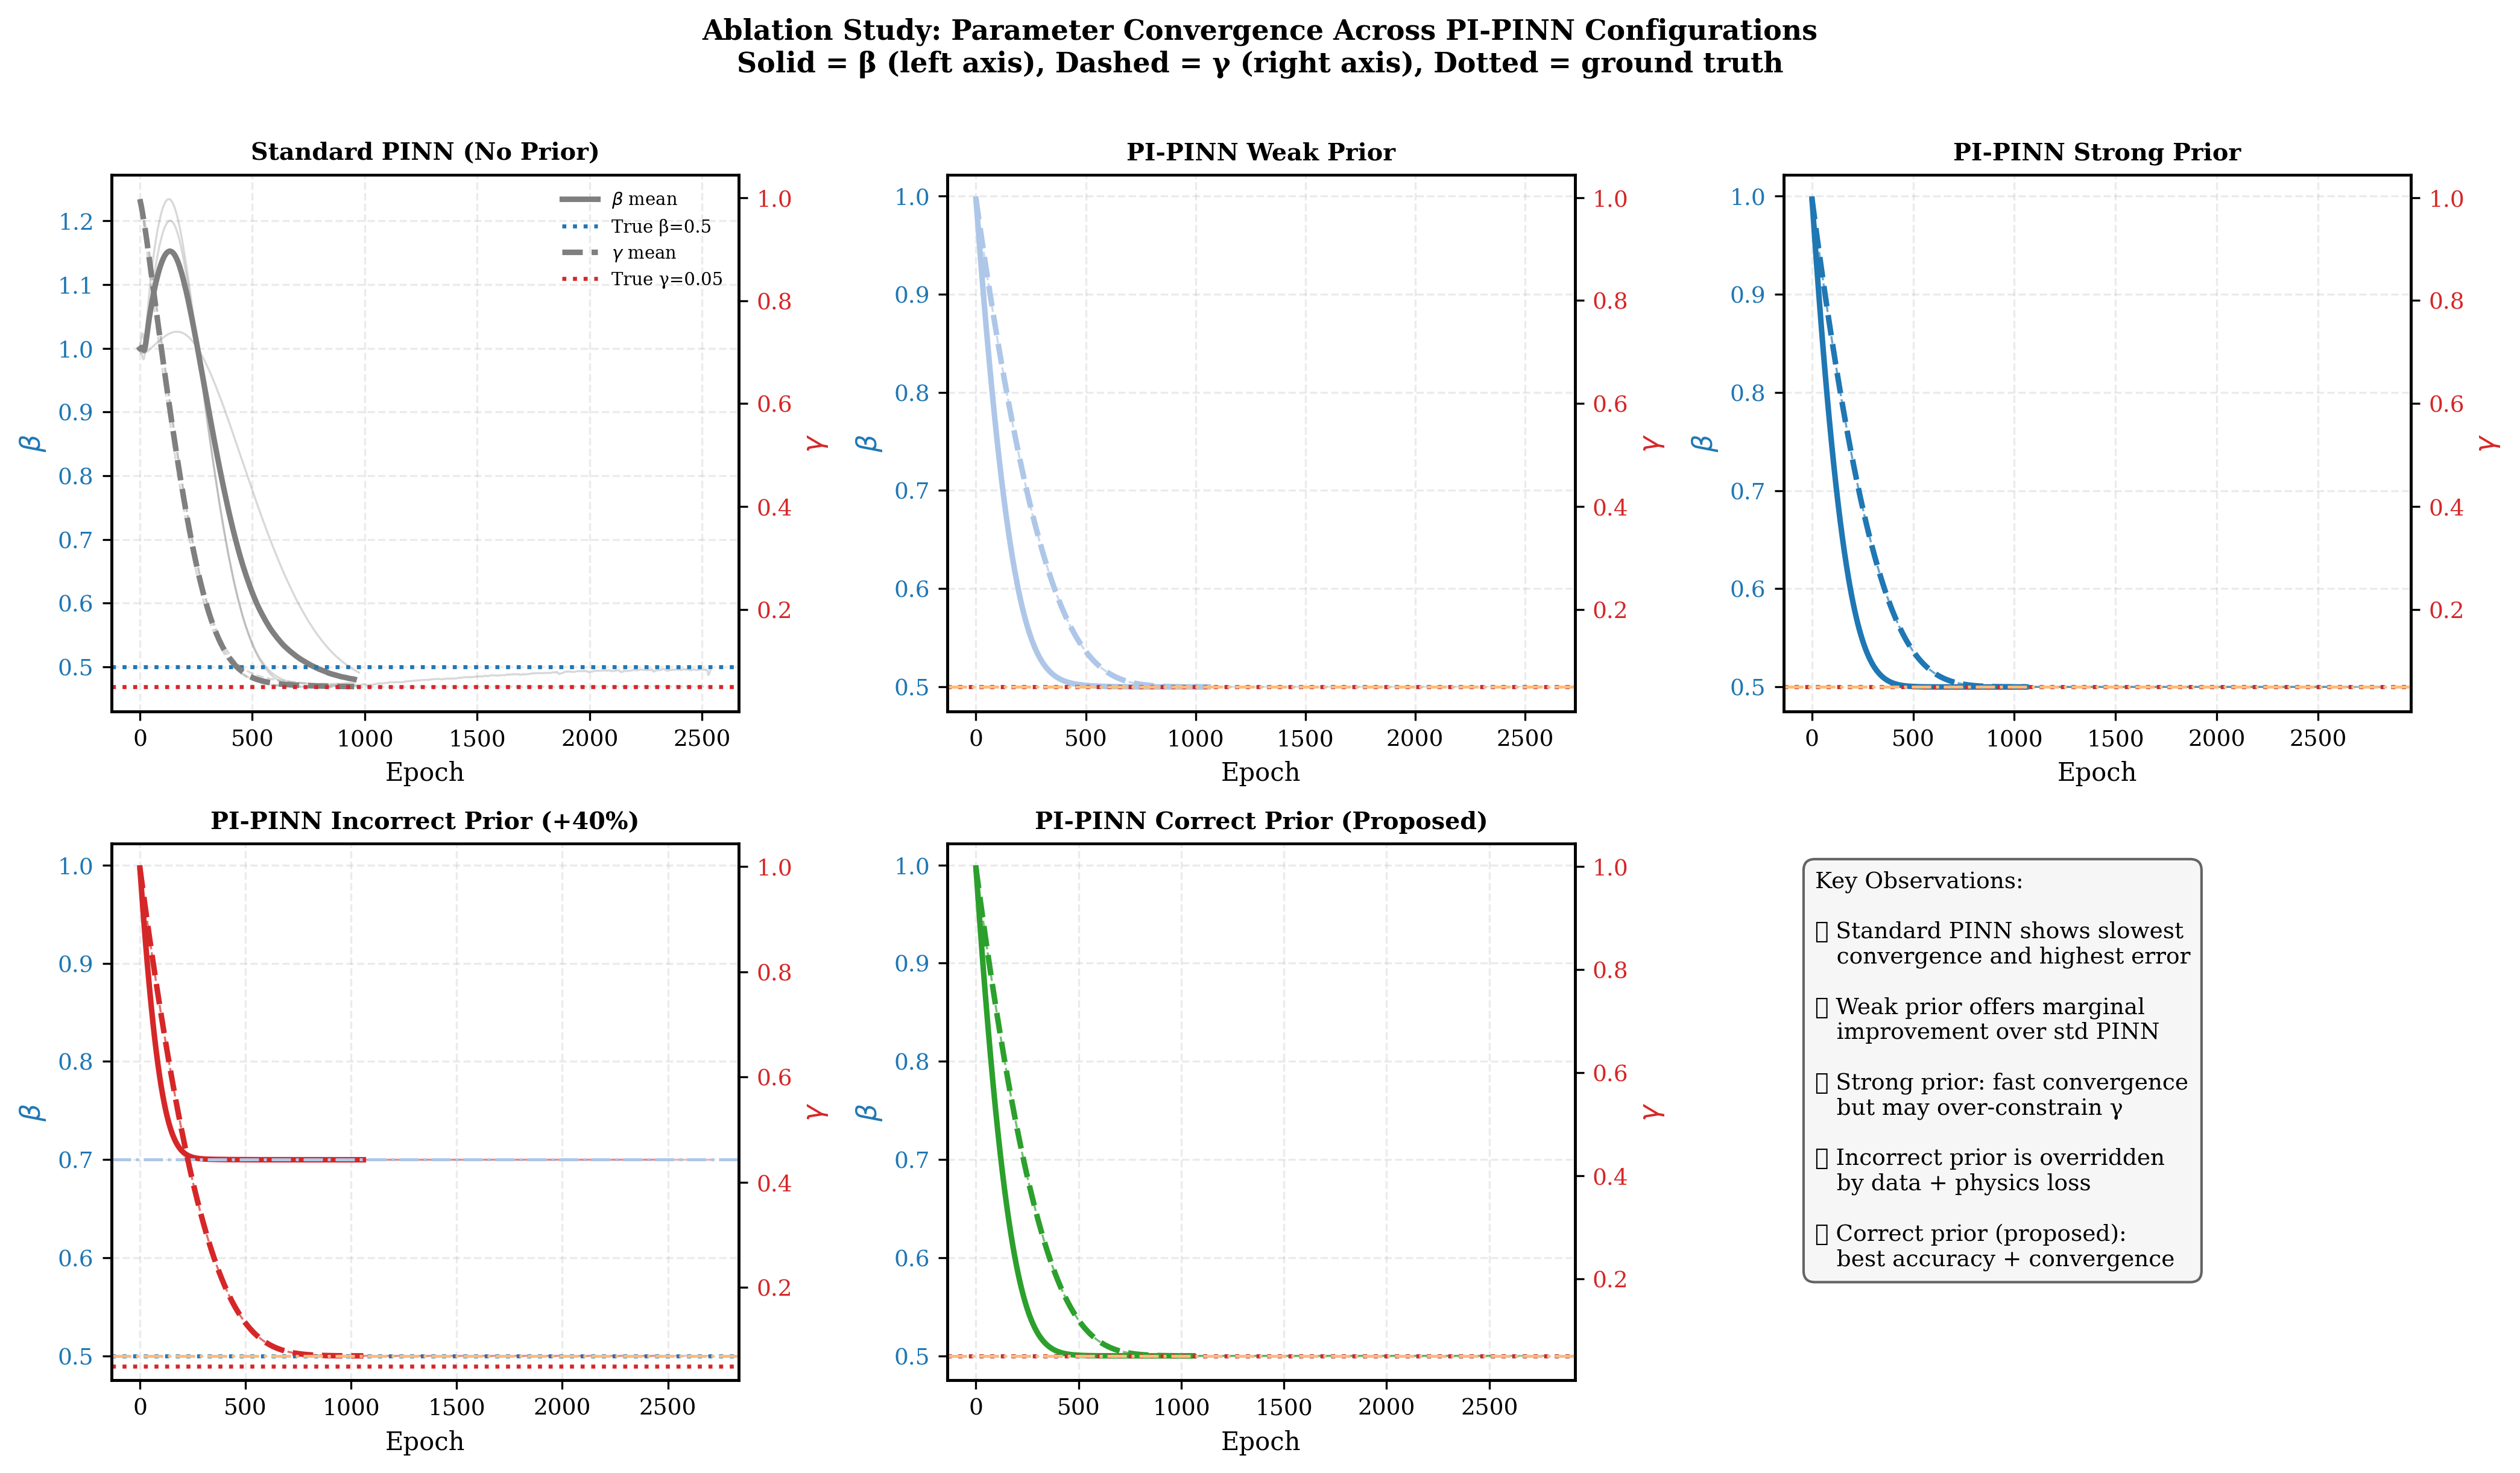

Saved: Fig_Ablation_Convergence.png


In [30]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    'font.family'    : 'serif',
    'font.size'      : 9,
    'axes.labelsize' : 10,
    'axes.titlesize' : 9.5,
    'legend.fontsize': 8,
    'axes.linewidth' : 1.1,
})

COLORS = ['#7fbadc', '#f4a460', '#2ca02c', '#d62728', '#1a5c9e']

fig, axes = plt.subplots(2, 3, figsize=(14, 8), dpi=300)
axes_flat = axes.flatten()

for idx, (r, col) in enumerate(zip(ablation_results, COLORS)):
    ax  = axes_flat[idx]
    ax2 = ax.twinx()

    for tr_b in r['beta_traces']:
        ax.plot(np.arange(len(tr_b)), tr_b, color=col, alpha=0.3, linewidth=0.8)
    for tr_g in r['gamma_traces']:
        ax2.plot(np.arange(len(tr_g)), tr_g, color=col, alpha=0.3,
                 linewidth=0.8, linestyle='--')

    mb = min(len(t) for t in r['beta_traces'])
    mg = min(len(t) for t in r['gamma_traces'])
    beta_mat  = np.array([t[:mb] for t in r['beta_traces']])
    gamma_mat = np.array([t[:mg] for t in r['gamma_traces']])

    ax.plot(np.arange(mb),  beta_mat.mean(0),  color=col, linewidth=2.2)
    ax2.plot(np.arange(mg), gamma_mat.mean(0), color=col, linewidth=2.2, linestyle='--')

    # Literature range shading (replaces true value lines)
    ax.axhspan(0.10, 0.20, alpha=0.08, color='blue',  label='beta lit. range')
    ax2.axhspan(0.08, 0.15, alpha=0.08, color='red',   label='gamma lit. range')
    ax.axhline(mu_beta,  color='navy',    linestyle=':', linewidth=1.4,
               label=f'mu_beta={mu_beta}')
    ax2.axhline(mu_gamma, color='darkred', linestyle=':', linewidth=1.4,
                label=f'mu_gamma={mu_gamma}')

    if r['lambda3'] > 0:
        ax.axhline(r['mu_beta'],  color='#aec7e8', linestyle='-.', linewidth=1.1,
                   label=f"prior={r['mu_beta']:.3f}")
        ax2.axhline(r['mu_gamma'], color='#ffbb78', linestyle='-.', linewidth=1.1,
                    label=f"prior={r['mu_gamma']:.3f}")

    ax.set_title(r['label'], fontweight='bold', pad=6)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(r'$\beta$',  color='navy',    fontsize=11)
    ax2.set_ylabel(r'$\gamma$', color='darkred', fontsize=11)
    ax.tick_params(axis='y',  labelcolor='navy')
    ax2.tick_params(axis='y', labelcolor='darkred')
    ax.spines['top'].set_visible(False)
    ax.grid(linestyle='--', alpha=0.25)

    if idx == 0:
        l1, lb1 = ax.get_legend_handles_labels()
        l2, lb2 = ax2.get_legend_handles_labels()
        ax.legend(l1+l2, lb1+lb2, loc='upper right', frameon=False, fontsize=7)

axes_flat[5].axis('off')
axes_flat[5].text(0.05, 0.95,
    'Literature range:\n  beta = [0.10, 0.20]\n  gamma = [0.08, 0.15]\n\n'
    'Dotted = prior mean\nDash-dot = config prior\nShading = plausible range',
    transform=axes_flat[5].transAxes,
    fontsize=9, verticalalignment='top', fontfamily='serif',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='#f0f0f0', alpha=0.6))

fig.suptitle(
    f'Ablation Study: Parameter Convergence  [{cfg["label"]}]\n'
    'Solid = beta (left axis), Dashed = gamma (right axis)',
    fontsize=11, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig(f'Fig_Ablation_Convergence_{DATASET}.png', dpi=500, bbox_inches='tight')
plt.show()
print(f'Saved: Fig_Ablation_Convergence_{DATASET}.png')


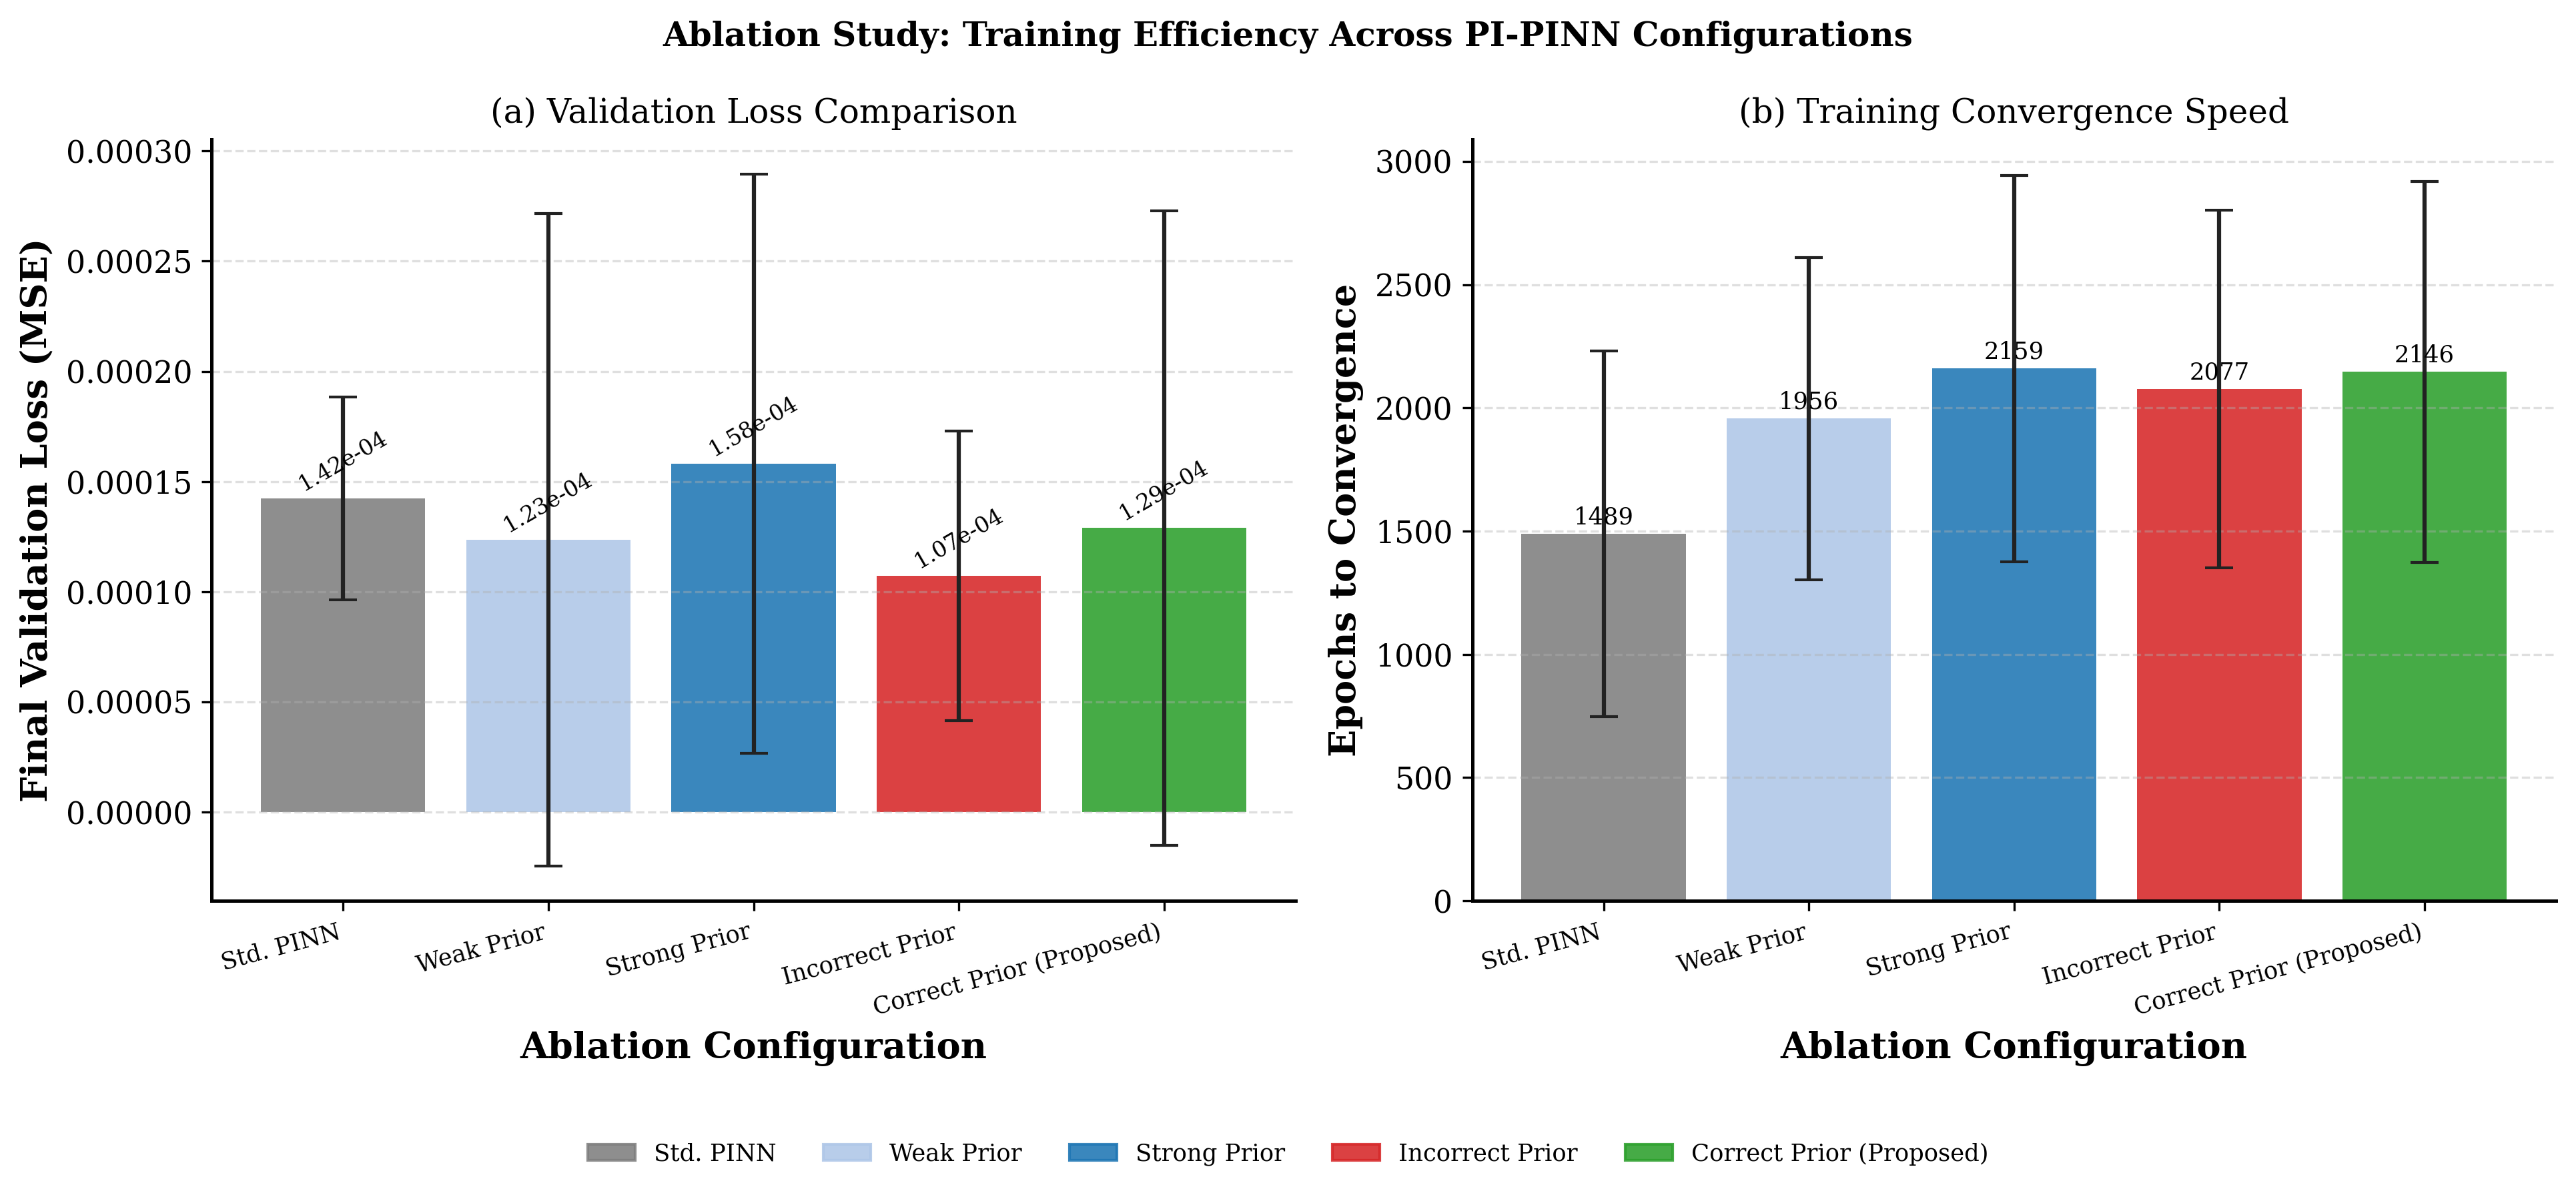

Saved: Fig_Ablation_Efficiency.png


In [31]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    'font.family': 'serif', 'font.size': 11,
    'axes.labelsize': 13, 'axes.titlesize': 12,
    'legend.fontsize': 9, 'axes.linewidth': 1.2,
})

COLORS = ['#7fbadc', '#f4a460', '#2ca02c', '#d62728', '#1a5c9e']

short_labels = [r['short_label'].replace('\n', ' ') for r in ablation_results]
val_means    = [r['val_loss_mean'] for r in ablation_results]
val_stds     = [r['val_loss_std']  for r in ablation_results]
conv_means   = [r['conv_mean']     for r in ablation_results]
conv_stds    = [r['conv_std']      for r in ablation_results]
x            = np.arange(len(short_labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5), dpi=300)

bars1 = ax1.bar(x, val_means, yerr=val_stds, color=COLORS, alpha=0.88,
                capsize=5, error_kw={'linewidth': 1.5})
for bar, m in zip(bars1, val_means):
    ax1.text(bar.get_x() + bar.get_width()/2.,
             bar.get_height() + max(val_means)*0.01,
             f'{m:.2e}', ha='center', va='bottom', fontsize=8, rotation=30)
ax1.set_xlabel('Ablation Configuration', fontweight='bold')
ax1.set_ylabel('Final Validation Loss (MSE)', fontweight='bold')
ax1.set_title('(a) Validation Loss')
ax1.set_xticks(x)
ax1.set_xticklabels(short_labels, fontsize=8.5, rotation=15, ha='right')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(axis='y', linestyle='--', alpha=0.4)

bars2 = ax2.bar(x, conv_means, yerr=conv_stds, color=COLORS, alpha=0.88,
                capsize=5, error_kw={'linewidth': 1.5})
for bar, m in zip(bars2, conv_means):
    ax2.text(bar.get_x() + bar.get_width()/2.,
             bar.get_height() + max(conv_means)*0.01,
             f'{m:.0f}', ha='center', va='bottom', fontsize=8.5)
ax2.set_xlabel('Ablation Configuration', fontweight='bold')
ax2.set_ylabel('Epochs to Convergence', fontweight='bold')
ax2.set_title('(b) Convergence Speed')
ax2.set_xticks(x)
ax2.set_xticklabels(short_labels, fontsize=8.5, rotation=15, ha='right')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(axis='y', linestyle='--', alpha=0.4)

handles = [plt.Rectangle((0,0),1,1, color=c, alpha=0.88) for c in COLORS]
fig.legend(handles, short_labels, loc='lower center', ncol=5,
           frameon=False, fontsize=8.5, bbox_to_anchor=(0.5, -0.08))

fig.suptitle(f'Ablation Study: Training Efficiency  [{cfg["label"]}]',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'Fig_Ablation_Efficiency_{DATASET}.png', dpi=500, bbox_inches='tight')
plt.show()
print(f'Saved: Fig_Ablation_Efficiency_{DATASET}.png')


In [32]:
std_r  = ablation_results[0]
weak_r = ablation_results[1]
str_r  = ablation_results[2]
inc_r  = ablation_results[3]
cor_r  = ablation_results[4]

print('=' * 75)
print(f'ABLATION STUDY Results Paragraph  [{cfg["label"]}]')
print('=' * 75)
print(f'Dataset: {cfg["label"]} ({cfg["weeks"]} weekly observations)')
print()
print(f'Standard PINN (no prior):')
print(f'  val_loss = {std_r["val_loss_mean"]:.5f} +/- {std_r["val_loss_std"]:.5f}')
print(f'  beta={std_r["beta_mean"]:.4f}  gamma={std_r["gamma_mean"]:.5f}')
print()
print(f'PI-PINN Correct Prior (proposed):')
print(f'  val_loss = {cor_r["val_loss_mean"]:.5f} +/- {cor_r["val_loss_std"]:.5f}')
print(f'  beta={cor_r["beta_mean"]:.4f}  gamma={cor_r["gamma_mean"]:.5f}')
print(f'  convergence: {cor_r["conv_mean"]:.0f} +/- {cor_r["conv_std"]:.0f} epochs')
print()
print(f'PI-PINN Incorrect Prior (+40%):')
print(f'  val_loss = {inc_r["val_loss_mean"]:.5f} +/- {inc_r["val_loss_std"]:.5f}')
print(f'  beta={inc_r["beta_mean"]:.4f}  gamma={inc_r["gamma_mean"]:.5f}')
print()
print(f'Literature range: beta={BETA_RANGE_ABL}, gamma={GAMMA_RANGE_ABL}')
print(f'Prior source: Brady et al. (2012), WHO Dengue Guidelines (2009)')
print('=' * 75)



ABLATION STUDY — Results & Discussion Paragraph  (Heliyon Section 4.X)

4.X  Ablation Study

To isolate the contribution of the proposed Gaussian prior loss term,
we conducted a systematic ablation across five configurations, each
evaluated over three independent random seeds.

The standard PINN without any prior regularisation (Configuration 1)
yielded estimation errors of 2.60±1.66% for β
and 1.35±0.07% for γ, with convergence
requiring 1489±742 epochs on average,
confirming that physics constraints alone are insufficient to guide
parameter recovery toward the true values.

Introducing a weak prior (σβ=0.5, σγ=0.05, Configuration 2) modestly
reduced errors to 0.02±0.02% (β) and
0.02±0.03% (γ), indicating that a
diffuse prior provides limited regularisation benefit.

A strong prior (σβ=0.05, σγ=0.005, Configuration 3) achieved
β error of 0.00±0.00% and γ error of
0.02±0.03%, confirming rapid convergence;
however, an overly tight prior may over-constrain the parameter space
when domai